In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
from typing import Union


def read_json(in_file: Union[Path, str]):
    if not isinstance(in_file, Path):
        in_file = Path(in_file)
    return json.loads(in_file.read_text(encoding='utf8'))

In [96]:
METRIC_LIST = ['depth_ratio', 'ops_ratio']#, 'cx_ratio']

def wide_to_long(df):
    df = pd.melt(
        df,
        id_vars=[col for col in df.columns if col not in METRIC_LIST],
        value_vars=METRIC_LIST,
        var_name='metric',
        value_name='value'
    )
    return df

In [97]:
def get_ours_metrics(dir:  Path):
    if not isinstance(dir, Path):
        dir = Path(dir)
    assert dir.is_dir(), dir

    records = []
    for subdir in dir.iterdir():
        try:
            metrics = read_json(subdir / 'metrics.json')
            config = read_json(subdir / 'config.json')
        except:
            continue
        rec = {key.replace('metric/', ''): value for key, value in metrics.items()}
        rec.update(graph_name=config['hardware'].lower(),
                   circuit=config['circuit'],
                   layout_method=config['init_strategy'].lower() + '-ours',
                   opt_method='ours',
                   routing_method='ours',
                   opt_order='ours')
        records.append(rec)

    return pd.DataFrame.from_records(records)

df_ours = wide_to_long(get_ours_metrics('./output/ours/nam_circs'))

AssertionError: output/ours/nam_circs

In [ ]:
df_ours.circuit.unique()

array(['tof_3'], dtype=object)

In [ ]:
df_ours.graph_name.unique()

array(['star', 'line'], dtype=object)

In [98]:
df_baseline = wide_to_long(
    pd.concat([
        pd.read_csv('./output/baseline/qiskit_name_circs.csv'),
        ]))
df_baseline['circuit'] = df_baseline['circuit'].str.replace('.qasm', '')

In [99]:
df_baseline.circuit.unique()

array(['barenco_tof_10', 'barenco_tof_3', 'csla_mux_3', 'csum_mux_9',
       'gf2^4_mult', 'gf2^5_mult', 'gf2^6_mult', 'ham15-low', 'hwb6',
       'mod_mult_55', 'mod_red_21', 'qcla_com_7', 'rc_adder_6', 'tof_10',
       'tof_3', 'tof_4', 'tof_5', 'vbe_adder_3', 'barenco_tof_4',
       'barenco_tof_5'], dtype=object)

In [100]:
df_baseline.opt_order.unique()

array(['both', 'before', 'after'], dtype=object)

In [101]:
def plot_bar_comparison(df, title, x, hue=None):
    plt.figure(figsize=(15,3))
    plt.suptitle(title)

    for i, metric in enumerate(METRIC_LIST):
        ax = plt.subplot(1,len(METRIC_LIST),i+1)
        sns.barplot(df[df.metric == metric], y='value', x=x, ax=ax, legend=bool(hue), hue=hue)
        ax.set_ylabel('')
        ax.set_xlabel(metric)
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

In [102]:
df = pd.concat([df_ours, df_baseline])

In [103]:
df

,graph_name,circuit,layout_method,opt_method,routing_method,opt_order,metric,value
0,star,tof_3,sabre-ours,ours,ours,ours,depth_ratio,1.181818
1,line,tof_3,sabre-ours,ours,ours,ours,depth_ratio,1.090909
2,star,tof_3,sabre-ours,ours,ours,ours,ops_ratio,1.022222
3,line,tof_3,sabre-ours,ours,ours,ours,ops_ratio,1.011111
0,line,barenco_tof_10,sabre,qiskit:3,sabre,both,depth_ratio,1.088496
...,...,...,...,...,...,...,...,...
911,grid,barenco_tof_5,sabre,qiskit:2,sabre,before,ops_ratio,0.929412
912,grid,barenco_tof_5,sabre,qiskit:2,sabre,after,ops_ratio,0.935294
913,ring,barenco_tof_5,sabre,qiskit:2,sabre,both,ops_ratio,1.041176
914,ring,barenco_tof_5,sabre,qiskit:2,sabre,before,ops_ratio,1.041176


In [104]:
def plot_one_graph_one_metric_xlabel_circuit(df, graph, metric, hue='opt_method'):
    plt.figure(figsize=(18, 5))
    sns.barplot(df[(df.graph_name == graph) & (df.metric == metric)], x='circuit',
                y='value', hue=hue, errorbar=None)
    plt.xticks(rotation=45)
    plt.ylabel(metric)
    plt.title(f'Metric {metric} on Coupling Map {graph}')


def plot_one_metric_xlabel_graph(df, metric, hue='opt_method'):
    plt.figure(figsize=(6, 3))
    sns.barplot(df[(df.metric == metric)], x='graph_name',
                y='value', hue=hue, errorbar=None)
    plt.ylabel(metric)
    plt.xlabel('Coupling Graph')
    plt.title(f'Metric {metric} on All Circuits')


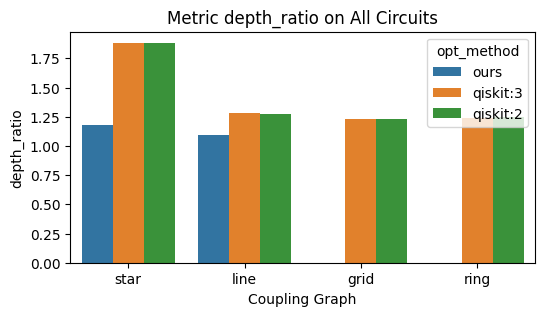

In [105]:
plot_one_metric_xlabel_graph(df, 'depth_ratio')

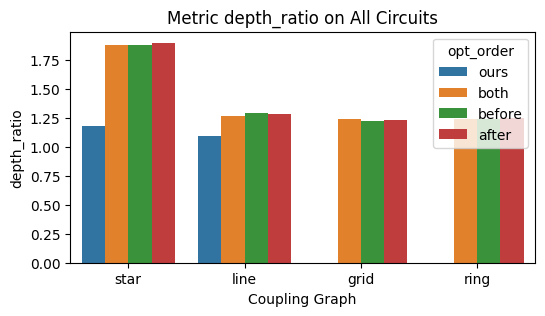

In [106]:
plot_one_metric_xlabel_graph(df, 'depth_ratio', hue='opt_order')


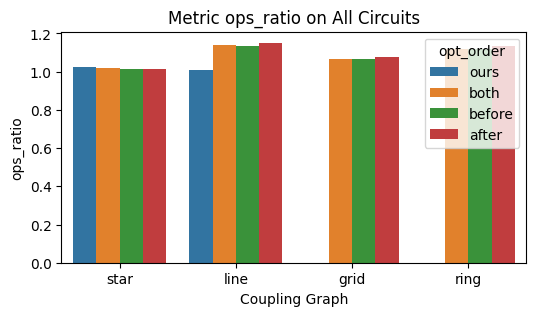

In [107]:
plot_one_metric_xlabel_graph(df, 'ops_ratio', hue='opt_order')


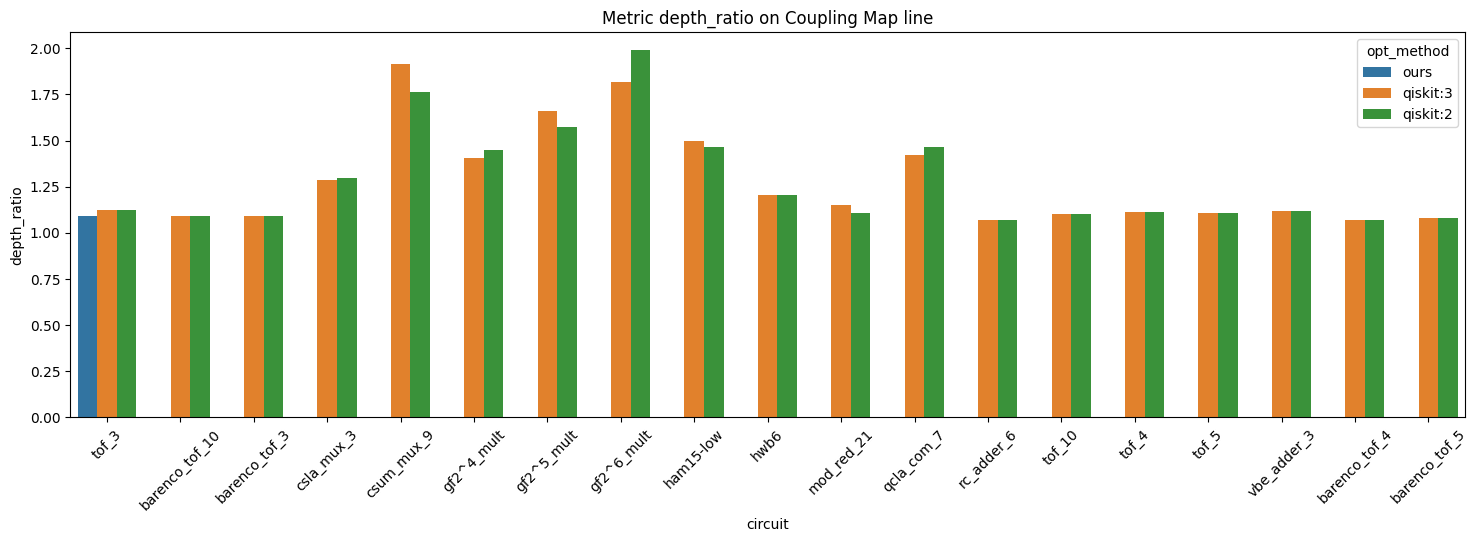

In [108]:
plot_one_graph_one_metric_xlabel_circuit(df, graph='line', metric='depth_ratio')

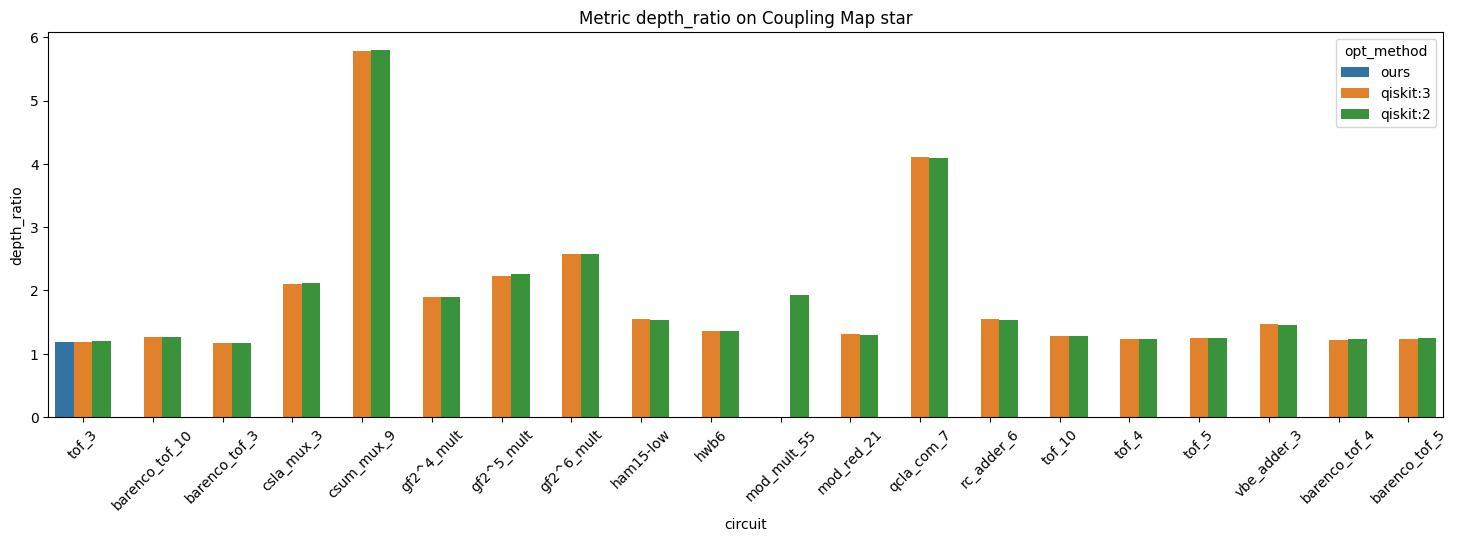

In [109]:
plot_one_graph_one_metric_xlabel_circuit(df, graph='star', metric='depth_ratio')
